In [1]:
import matplotlib.pyplot as plt

import pydpeet as eet

eet.set_logging_style("ERROR")

In [2]:
Data = eet.read(config="neware_8_0_0_516", input_path=r"..\..\res\raw\Cal_Ageing_Checkup3.xlsx")
Data.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A]
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,None
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,None
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,None
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,None
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,None


In [3]:
Data_segmented = eet.add_primitive_segments(Data)
Data_segmented.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],...,ID,Variable,Duration,Length,Min,Max,Avg,Type,Direction,Slope
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,...,1,I,8873,8872.0,1.4388,1.44,1.439794,Constant,Charge,-9.017133e-08


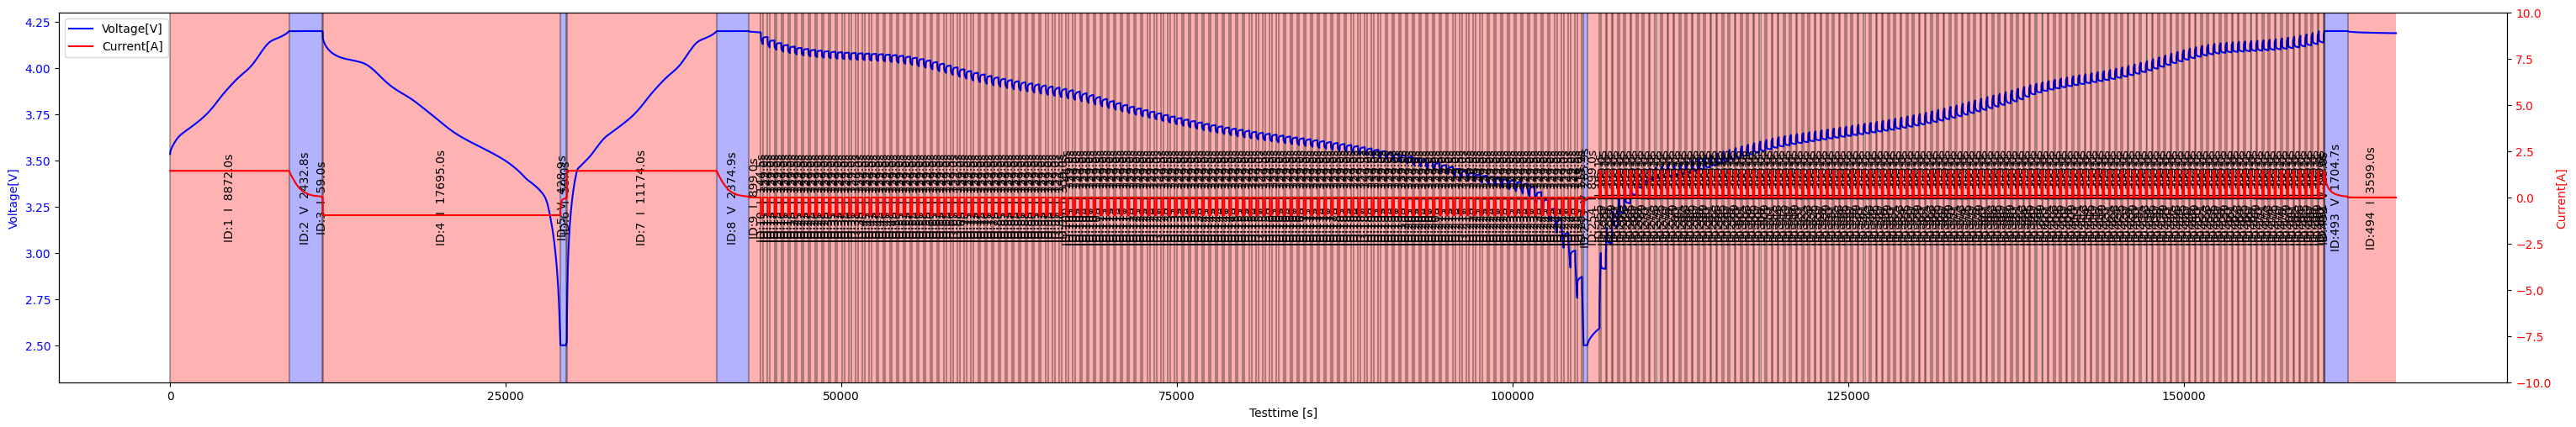

In [4]:
eet.visualize_phases(dataframe=Data_segmented)
plt.show()

In [5]:
Battery_Config = eet.lgm50lt_nmc_4800

# todo: is it possible to probide acces to the Batemo/About-Energy database and fetch battery configs directly from there?
# todo: or we download it and provide the databse directly?

results = eet.add_capacity(Data, Data_segmented, neware_bool=True, config=Battery_Config)  # todo: fix
results.head()

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],Capacity[Ah]
0.0,20240419100603-CheckUp-1-6-AM23NMC00009.xlsx U...,0,3.5353,1.4396,30.1,0.0,2024-04-19 10:06:03,None,None,None,None,NaN
1.0,None,0,3.5368,1.4397,30.1,1.0,2024-04-19 10:06:04,None,None,None,None,NaN
2.0,None,0,3.5379,1.4398,30.1,2.0,2024-04-19 10:06:05,None,None,None,None,NaN
3.0,None,0,3.5388,1.4398,29.9,3.0,2024-04-19 10:06:06,None,None,None,None,NaN
4.0,None,0,3.5396,1.4399,29.9,4.0,2024-04-19 10:06:07,None,None,None,None,NaN


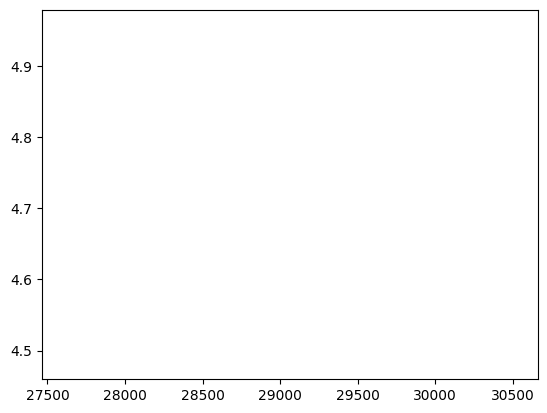

In [6]:
fig, ax = plt.subplots()
ax.plot(Data["Test_Time[s]"], results["Capacity[Ah]"])